# **Review Classification**
**Objective:** Classify customer reviews into positive, negative, or neutral categories to help the company improve its products and services.

**Task:** Create a model for classifying the textual content of reviews into these three categories.


## Section 1: Load and Preprocess the Dataset
Loads and processes the Amazon Reviews 2023 dataset (using the “raw_review_All_Beauty” configuration).

In [1]:
!pip install datasets

In [2]:
# Import Required Packages

import numpy as np
import datasets
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report


In [3]:
# Suppress unnecessary logging from the datasets library
datasets.logging.set_verbosity_error()

In [4]:
# Load the raw reviews dataset for All Beauty from Hugging Face
raw_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
                           "raw_review_All_Beauty",
                           trust_remote_code=True)

# The dataset is in the "full" split; check first sample structure.
print("Sample Raw Review:")
print(raw_dataset["full"][0])
print("\n")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sample Raw Review:
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}




## Section 2: Explore the dataset

In [5]:

# Import Required Libraries
import matplotlib.pyplot as plt

# Print the names of the columns available in the "full" split
print("Dataset Columns:", raw_dataset["full"].column_names)



Dataset Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [6]:
# Display the first 3 records to inspect the data
print("\nFirst 3 Samples:")
for i, sample in enumerate(raw_dataset["full"][:3]):
    print(f"Sample {i+1}:", sample)
    print("-" * 50)



First 3 Samples:
Sample 1: rating
--------------------------------------------------
Sample 2: title
--------------------------------------------------
Sample 3: text
--------------------------------------------------
Sample 4: images
--------------------------------------------------
Sample 5: asin
--------------------------------------------------
Sample 6: parent_asin
--------------------------------------------------
Sample 7: user_id
--------------------------------------------------
Sample 8: timestamp
--------------------------------------------------
Sample 9: helpful_vote
--------------------------------------------------
Sample 10: verified_purchase
--------------------------------------------------


In [7]:
# Get the total number of samples in the 'full' split
num_samples = len(raw_dataset["full"])
print("\nTotal Samples in 'full' Split:", num_samples)


Total Samples in 'full' Split: 701528



Ratings Summary:
Min rating: 1.0
Max rating: 5.0
Average rating: 3.9602453501499584


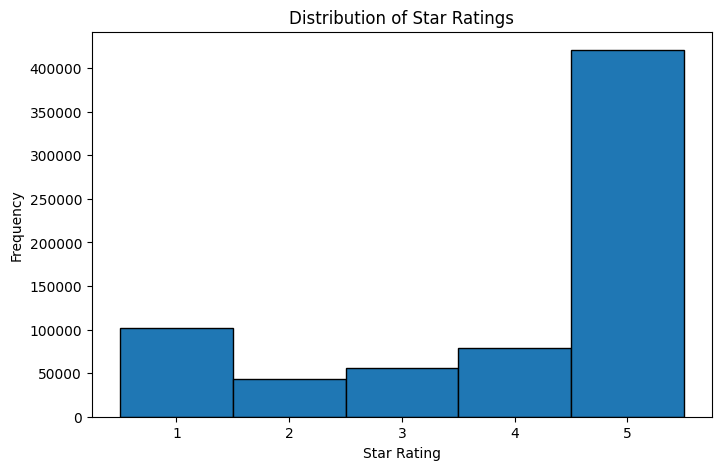

In [8]:
# Explore Rating Distribution
# Ratings are stored as strings (or numbers). Convert them to floats.
ratings = [float(record["rating"]) for record in raw_dataset["full"]]
print("\nRatings Summary:")
print("Min rating:", min(ratings))
print("Max rating:", max(ratings))
print("Average rating:", sum(ratings) / len(ratings))

# Plot a histogram to show the distribution of star ratings
plt.figure(figsize=(8, 5))
plt.hist(ratings, bins=[1,2,3,4,5,6], edgecolor="black", align="left")
plt.xlabel("Star Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Star Ratings")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

**observations and considerations:**

- **Skewed Distribution**
    1. The distribution shows a strong concentration of 5-star reviews. This is typical in many product reviews datasets, where satisfied customers often outnumber unsatisfied ones.

    2. The dataset is heavily skewed toward the “positive” side.

So, we will perform additional EDA to see if the skewness is consistent across subcategories (e.g., certain brands or product types) or if some have a more balanced distribution.

**Additional EDA: Rating Distribution Across Subcategories (Stores/Brands)**

In [9]:
# Import pandas for DataFrame manipulation
import pandas as pd

# Load the Item Metadata Dataset
# Using the "raw_meta_All_Beauty" configuration to obtain product-related information.
meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
                            "raw_meta_All_Beauty",
                            split="full",
                            trust_remote_code=True)

# Convert both datasets to Pandas DataFrames for easier merging
reviews_df = raw_dataset["full"].to_pandas()  # your reviews dataset already loaded earlier
meta_df = meta_dataset.to_pandas()

In [10]:
# Merge Reviews with Metadata
# Merge on "parent_asin" to combine review info with metadata (which contains, for instance, the "store" field)
merged_df = pd.merge(reviews_df, meta_df[['parent_asin', 'store']], on="parent_asin", how="inner")

print("Merged DataFrame (first 5 rows):")
print(merged_df.head())
print("\n")

Merged DataFrame (first 5 rows):
   rating                                      title  \
0     5.0  Such a lovely scent but not overpowering.   
1     4.0     Works great but smells a little weird.   
2     5.0                                       Yes!   
3     1.0                          Synthetic feeling   
4     5.0                                         A+   

                                                text images        asin  \
0  This spray is really nice. It smells really go...     []  B00YQ6X8EO   
1  This product does what I need it to do, I just...     []  B081TJ8YS3   
2                          Smells good, feels great!     []  B07PNNCSP9   
3                                     Felt synthetic     []  B09JS339BZ   
4                                            Love it     []  B08BZ63GMJ   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B00YQ6X8EO  AGKHLEW2SOWHNMFQIJGBECAF7INQ  1588687728923             0   
1  B081TJ8YS3  AGKHLEW2SOWH

Top 10 Stores by Number of Reviews:
store
PHILIPS              2966
Segbeauty            2321
YMHPRIDE             2196
SALUX                2183
Lume                 2174
Bath & Body Works    2150
Premium Nature       1970
WILLBOND             1907
Godefroy             1752
TIGI                 1721
Name: count, dtype: int64




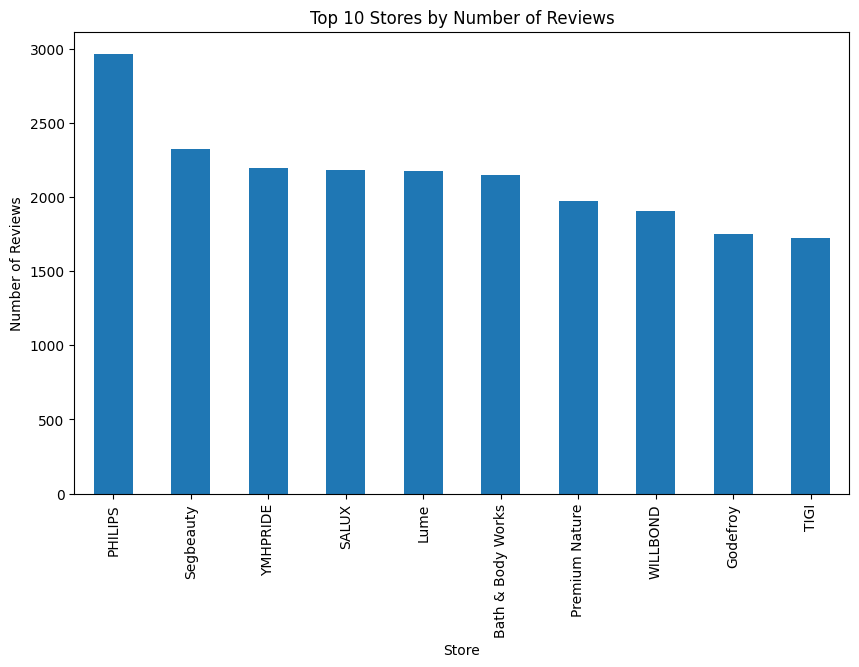

In [11]:
# Analyze Review Counts Per Store (Subcategory)
# Determine which stores (or brands) have the most reviews
store_counts = merged_df['store'].value_counts()
print("Top 10 Stores by Number of Reviews:")
print(store_counts.head(10))
print("\n")

# Plot the top 10 stores by review count
plt.figure(figsize=(10, 6))
store_counts.head(10).plot(kind="bar")
plt.xlabel("Store")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Stores by Number of Reviews")
plt.show()

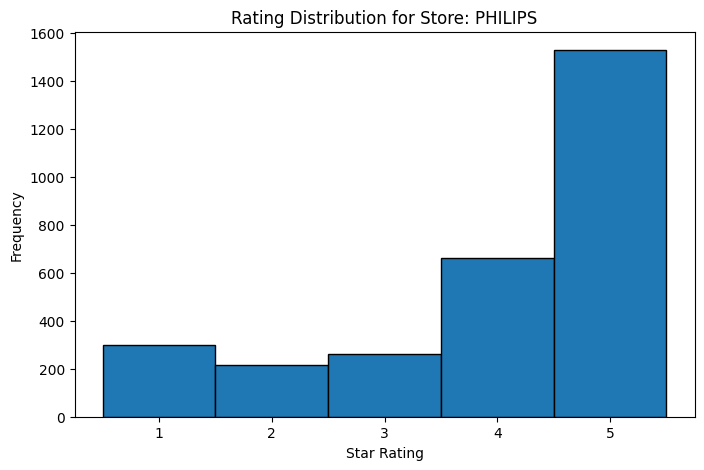

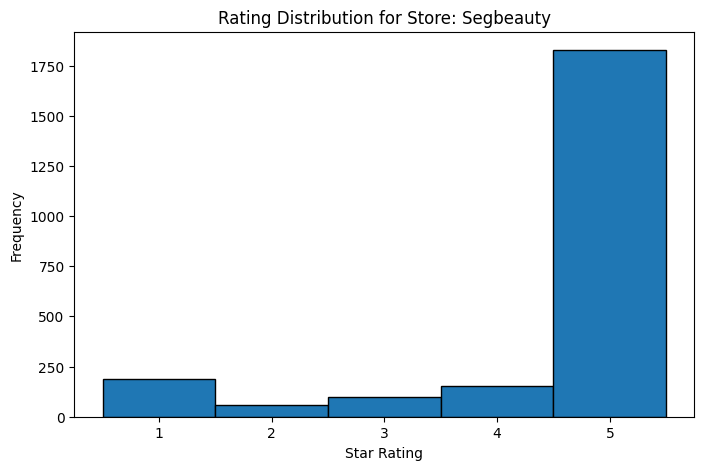

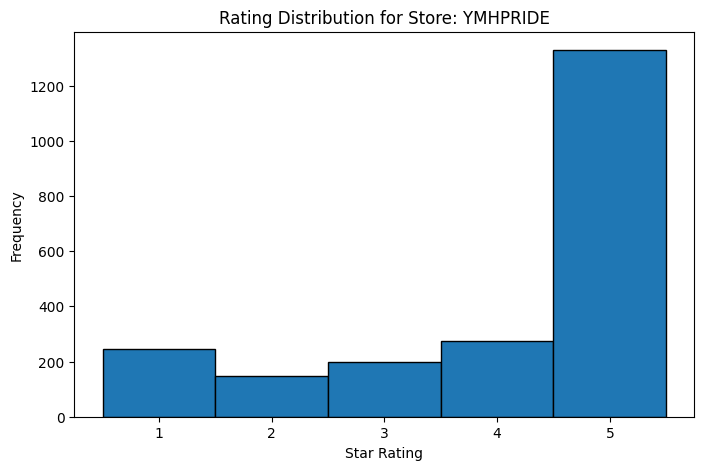

In [12]:
# Explore Rating Distribution for Top Stores
# For a deeper look into rating skewness, analyze rating distributions for the top 3 stores.
top_stores = store_counts.index[:3]

for store in top_stores:
    # Filter the merged dataframe for a specific store
    subset = merged_df[merged_df["store"] == store]
    # Convert the ratings to float if necessary
    ratings_store = subset["rating"].astype(float)

    plt.figure(figsize=(8, 5))
    plt.hist(ratings_store, bins=[1, 2, 3, 4, 5, 6], edgecolor="black", align="left")
    plt.xlabel("Star Rating")
    plt.ylabel("Frequency")
    plt.title(f"Rating Distribution for Store: {store}")
    plt.xticks([1, 2, 3, 4, 5])
    plt.show()

**Observations**
- **Overall Skewness:**
    All histograms suggest an overall positive skew where the majority of the reviews are in the higher ratings (4-5 stars). This is common in online review datasets, but it's crucial to address this when training models for sentiment analysis.

- **Class Imbalance Considerations for Modeling:**
    When mapping ratings into three sentiment classes (negative: 1-2, neutral: 3, positive: 4-5), the "positive" class will have far more samples than the "neutral" or "negative" classes. Techniques such as class weighting, oversampling the minority classes, or undersampling the majority class should be considered during model training.

- **Evaluation Metrics:**
    Given the imbalance, it’s important to use evaluation metrics that provide insight beyond overall accuracy. Consider using precision, recall, and F1-score for each class along with a confusion matrix to better understand misclassifications and to ensure your model performs well across all sentiment categories.



**Maps star ratings into three sentiment classes:**

- Ratings 1–2 → Negative

- Rating 3 → Neutral

- Ratings 4–5 → Positive

In [13]:
# Define a function to map star ratings (1 to 5) to three sentiment classes.
def map_sentiment_row(rating):
    r = float(rating)
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"



# Apply the mapping function to create a "sentiment" column
merged_df["sentiment"] = merged_df["rating"].apply(map_sentiment_row)


In [14]:
# Create a numeric mapping for the sentiment labels
sentiment_mapping = {"negative": 0, "neutral": 1, "positive": 2}
merged_df["label"] = merged_df["sentiment"].map(sentiment_mapping)

# Display the sentiment distribution
print("Sentiment Distribution:")
print(merged_df["sentiment"].value_counts())
print("\n")

Sentiment Distribution:
sentiment
positive    500107
negative    145114
neutral      56307
Name: count, dtype: int64




## Section 3: Split the Dataset

In [15]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Use stratified splitting on the numeric label to maintain class distribution.
train_df, test_df = train_test_split(merged_df, test_size=0.2, random_state=42, stratify=merged_df["label"])
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\n")

# Convert the Pandas DataFrames to Hugging Face Datasets.
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


Training set shape: (561222, 13)
Test set shape: (140306, 13)




## Section 4: Tokenize the Data
The raw text data is processed by the tokenizer. It converts the text into numerical IDs (stored in "input_ids") and creates an "attention_mask" that tells the model which tokens are actual data and which are just padding.


In [16]:
import torch
from transformers import DistilBertForSequenceClassification

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Define a tokenization function using the "text" column as the input.
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenizer on both train and test datasets in batched mode.
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set the format for PyTorch so that the Trainer can use the inputs.
columns_to_keep = ["input_ids", "attention_mask", "label"]
train_dataset.set_format(type="torch", columns=columns_to_keep)
test_dataset.set_format(type="torch", columns=columns_to_keep)

Map:   0%|          | 0/561222 [00:00<?, ? examples/s]

Map:   0%|          | 0/140306 [00:00<?, ? examples/s]

In [17]:
def map_sentiment_df(rating):
    r = float(rating)
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

# Define the numeric mapping for labels
label_mapping = {"negative": 0, "neutral": 1, "positive": 2}

# Apply the mapping to create new columns for sentiment string and numeric label.
merged_df["sentiment"] = merged_df["rating"].apply(map_sentiment_df)
merged_df["label"] = merged_df["sentiment"].map(label_mapping)

print("\nSample of merged data with sentiment labels:")
print(merged_df[["rating", "sentiment", "label"]].head())



Sample of merged data with sentiment labels:
   rating sentiment  label
0     5.0  positive      2
1     4.0  positive      2
2     5.0  positive      2
3     1.0  negative      0
4     5.0  positive      2


## Section 5: Prepare the Model for Fine-Tuning

In [18]:
# Load a pretrained DistilBERT model with a classification head set to 3 labels
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
from sklearn.utils.class_weight import compute_class_weight
# Compute class weights to mitigate imbalance using the training labels.
train_labels = np.array(train_dataset["label"]).astype(int)
class_weights = np.round(
    compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels), 2
)
print("\nComputed Class Weights:", class_weights)

# Convert the computed class weights to a torch tensor.
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)


Computed Class Weights: [1.61 4.15 0.47]


## Section 6: Define Training Arguments and Compute Metrics Function

In [20]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


## Section 7: Create and Run the Trainer

In [28]:
from transformers import Trainer
import torch

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract labels and remove them from inputs so model doesn’t compute its own loss
        labels = inputs.pop("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        # Weighted CrossEntropyLoss
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


In [ ]:
# Define the training arguments with epoch-based evaluation and saving
training_args = TrainingArguments(
    output_dir="./results",                       # Directory to save model results
    eval_strategy="epoch",                        # Evaluate at the end of each epoch
    save_strategy="epoch",                        # Save the model at the end of each epoch
    num_train_epochs=3,                           # Total number of training epochs
    per_device_train_batch_size=32,               # Training batch size per device (adjust to utilize A100 capabilities)
    per_device_eval_batch_size=32,                # Evaluation batch size per device
    learning_rate=2e-5,                           # Learning rate for training
    weight_decay=0.01,                            # Weight decay to prevent overfitting
    logging_dir="./logs",                         # Directory for storing logs
    logging_strategy="epoch",                     # Log training details at the end of each epoch
    load_best_model_at_end=True,                  # Automatically load the best model after training finishes
    fp16=True,                                    # Enable mixed precision (16-bit) training for speed-up
    gradient_accumulation_steps=2,                # Accumulate gradients to effectively increase batch size without memory issues
    dataloader_num_workers=4,                     # Number of worker threads for data loading
)

# Setup the trainer using WeightedLossTrainer
trainer = WeightedLossTrainer(
    model=model,                  # Your pre-defined model
    args=training_args,           # Training arguments defined above
    train_dataset=train_dataset,  # Your training dataset
    eval_dataset=test_dataset,    # Your evaluation/test dataset
    compute_metrics=compute_metrics,  # Function to compute evaluation metrics
)

# Start the training process
trainer.train()

Epoch,Training Loss,Validation Loss


**Plot the Training History**

In [ ]:
# Get the log history from the trainer after training
log_history = trainer.state.log_history

# Convert the log history (which is a list of dictionaries) into a DataFrame
df_logs = pd.DataFrame(log_history)

# Check if 'loss' exists in the logged metrics and plot it
if 'loss' in df_logs.columns:
    plt.figure(figsize=(8, 6))
    # Plot training loss over the training steps
    plt.plot(df_logs['step'], df_logs['loss'], label='Training Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss History')
    plt.legend()
    plt.show()
else:
    print("No training loss information is available in the log history.")

**Save the model**

In [ ]:
model.save_pretrained("results/sentiment_model")
tokenizer.save_pretrained("results/sentiment_model")

## Section 8: Evaluate the Model

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Obtain predictions and true labels from the test dataset
predictions, labels, _ = trainer.predict(test_dataset)

# Convert the prediction scores to predicted class labels using np.argmax
preds = np.argmax(predictions, axis=1)

# Print the classification report using scikit-learn's classification_report
print("Classification Report:")
print(classification_report(labels, preds, target_names=["negative", "neutral", "positive"]))


In [ ]:

# Compute the confusion matrix using the true labels and predicted labels
conf_matrix = confusion_matrix(labels, preds)
print("Confusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix with matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(np.unique(labels)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()